# ESCALAMIENTO

## DESPLAZAMIENTO

### Librerías

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Realizar la regresión sin modificación y después hacerla con la modificación por diferencia.

## 1. Importar los datos

Primero se corrige la importación de `matplotlib.pyplot` y se leen los salarios mínimos.

In [84]:
df_salarios = pd.read_csv("Salarios_minimos.csv")
df_salarios.head()
df_salarios.describe()

,Periodo,Salario
count,34.000000,34.000000
mean,2002.177353,39.560588
std,9.117739,23.233915
min,1988.250000,8.000000
25%,1995.075000,16.830000
50%,2001.500000,41.250000
75%,2009.750000,56.795000
max,2018.000000,88.360000


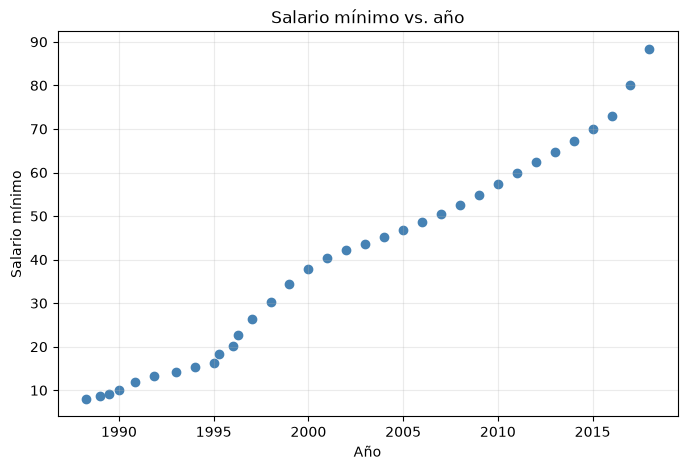

In [85]:
plt.figure(figsize=(8, 5))
plt.scatter(df_salarios["Periodo"], df_salarios["Salario"], color="steelblue")
plt.xlabel("Año")
plt.ylabel("Salario mínimo")
plt.title("Salario mínimo vs. año")
plt.grid(alpha=0.25)
plt.show()

## 2. Regresión sin modificación

Se utiliza directamente el año (`Periodo`) como variable independiente.

In [86]:
X_original = df_salarios[["Periodo"]]
y = df_salarios["Salario"]

modelo_original = LinearRegression()
modelo_original.fit(X_original, y)
pred_original = modelo_original.predict(X_original)

r2_original = modelo_original.score(X_original, y)
rmse_original = np.sqrt(mean_squared_error(y, pred_original))

print(f"Ecuación: Salario = {modelo_original.intercept_:.6f} "
      f"+ {modelo_original.coef_[0]:.6f}(Periodo)")
print(f"R²: {r2_original:.6f}")
print(f"RMSE: {rmse_original:.6f}")

Ecuación: Salario = -5022.602172 + 2.528329(Periodo)
R²: 0.984457
RMSE: 2.853724


## 3. Regresión con la modificación por diferencia

Se resta el primer periodo a todos los años:

$$Diferencia = Periodo - 1988.25$$

Así, el primer dato queda en 0 y los demás representan los años transcurridos desde 1988.25.

In [87]:
periodo_base = df_salarios["Periodo"].min()
df_salarios["Diferencia"] = df_salarios["Periodo"] - periodo_base

df_salarios[["Periodo", "Diferencia", "Salario"]].head(10)

,Periodo,Diferencia,Salario
0,1988.25,0.00,8.00
1,1989.00,0.75,8.64
2,1989.50,1.25,9.16
3,1990.00,1.75,10.08
4,1990.84,2.59,11.90
5,1991.84,3.59,13.33
6,1993.00,4.75,14.27
7,1994.00,5.75,15.27
8,1995.00,6.75,16.34
9,1995.30,7.05,18.30


In [88]:
X_diferencia = df_salarios[["Diferencia"]]

modelo_diferencia = LinearRegression()
modelo_diferencia.fit(X_diferencia, y)
pred_diferencia = modelo_diferencia.predict(X_diferencia)

r2_diferencia = modelo_diferencia.score(X_diferencia, y)
rmse_diferencia = np.sqrt(mean_squared_error(y, pred_diferencia))

print(f"Ecuación: Salario = {modelo_diferencia.intercept_:.6f} "
      f"+ {modelo_diferencia.coef_[0]:.6f}(Diferencia)")
print(f"R²: {r2_diferencia:.6f}")
print(f"RMSE: {rmse_diferencia:.6f}")

Ecuación: Salario = 4.347660 + 2.528329(Diferencia)
R²: 0.984457
RMSE: 2.853724


## 4. Comparación de los modelos

In [89]:
comparacion = pd.DataFrame({
    "Modelo": ["Sin modificación", "Con diferencia"],
    "Intercepto": [modelo_original.intercept_, modelo_diferencia.intercept_],
    "Pendiente": [modelo_original.coef_[0], modelo_diferencia.coef_[0]],
    "R²": [r2_original, r2_diferencia],
    "RMSE": [rmse_original, rmse_diferencia]
})

diferencia_maxima = np.max(np.abs(pred_original - pred_diferencia))
display(comparacion)
print(f"Diferencia máxima entre predicciones: {diferencia_maxima:.12f}")

,Modelo,Intercepto,Pendiente,R²,RMSE
0,Sin modificación,-5022.602172,2.528329,0.984457,2.853724
1,Con diferencia,4.347660,2.528329,0.984457,2.853724


Diferencia máxima entre predicciones: 0.000000000001


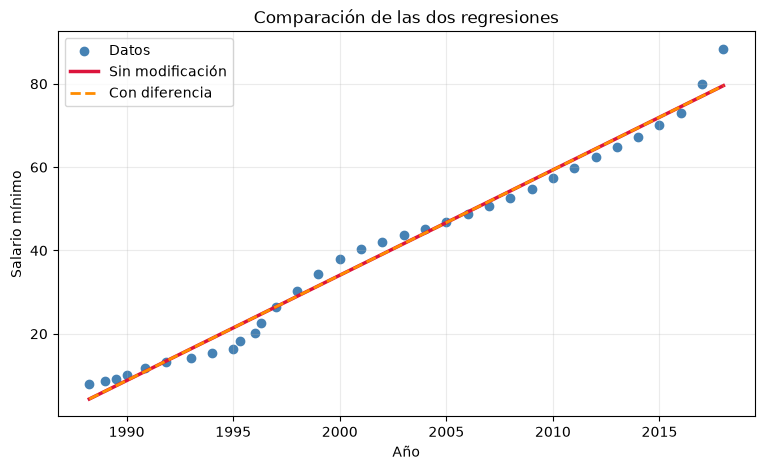

In [90]:
plt.figure(figsize=(9, 5))
plt.scatter(df_salarios["Periodo"], y, color="steelblue", label="Datos")
plt.plot(df_salarios["Periodo"], pred_original, color="crimson",
         linewidth=2.5, label="Sin modificación")
plt.plot(df_salarios["Periodo"], pred_diferencia, color="darkorange",
         linestyle="--", linewidth=2, label="Con diferencia")
plt.xlabel("Año")
plt.ylabel("Salario mínimo")
plt.title("Comparación de las dos regresiones")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 1. Importar datos de "bateria_tableta.txt"

In [91]:
import pandas as pd

df_bateria = pd.read_csv("bateria_tableta.txt")
print(df_bateria)
df_bateria.describe()

    carga  duracion
0    2.81      5.62
1    7.14      8.00
2    2.72      5.44
3    3.87      7.74
4    1.90      3.80
..    ...       ...
95   4.38      8.00
96   8.06      8.00
97   8.05      8.00
98   1.10      2.20
99   6.65      8.00

[100 rows x 2 columns]


,carga,duracion
count,100.000000,100.000000
mean,4.573000,6.206800
std,2.788603,2.454116
min,0.000000,0.000000
25%,1.987500,3.975000
50%,4.375000,8.000000
75%,6.522500,8.000000
max,11.720000,8.000000


## MIN - MAX

## **El dominio de carga es [0, 11.72], hay que cambiarlo a [1,2]**

In [92]:
df_bateria["carga_escalada"] = (
    1
    + ((df_bateria["carga"] - 0) / (11.72 - 0))
    * (2 - 1)
)

print(df_bateria[["carga", "carga_escalada"]])
df_bateria["carga_escalada"].describe()

    carga  carga_escalada
0    2.81        1.239761
1    7.14        1.609215
2    2.72        1.232082
3    3.87        1.330205
4    1.90        1.162116
..    ...             ...
95   4.38        1.373720
96   8.06        1.687713
97   8.05        1.686860
98   1.10        1.093857
99   6.65        1.567406

[100 rows x 2 columns]


count    100.000000
mean       1.390188
std        0.237935
min        1.000000
25%        1.169582
50%        1.373294
75%        1.556527
max        2.000000
Name: carga_escalada, dtype: float64

In [93]:
df_bateria["carga_escalada"] = 1 + df_bateria["carga"] / 11.72

In [94]:
carga_escalada = []

for carga in df_bateria["carga"]:
    nuevo_valor = 1 + ((carga - 0) / (11.72 - 0)) * (2 - 1)
    carga_escalada.append(nuevo_valor)

df_bateria["carga_escalada"] = carga_escalada

In [95]:
# Para comprobar

print("Mínimo:", df_bateria["carga_escalada"].min())  # 1
print("Máximo:", df_bateria["carga_escalada"].max())  # 2

Mínimo: 1.0
Máximo: 2.0


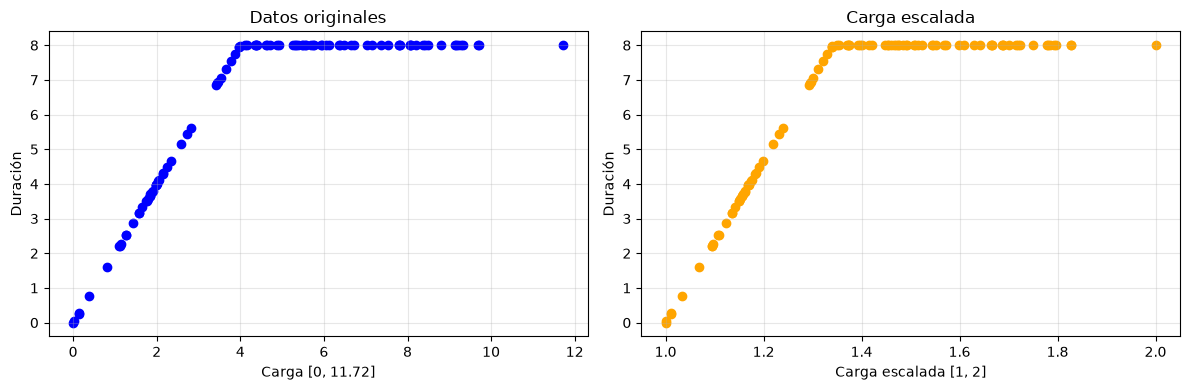

In [96]:
# Gráfica

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Datos originales
axes[0].scatter(
    df_bateria["carga"],
    df_bateria["duracion"],
    color="blue"
)
axes[0].set_title("Datos originales")
axes[0].set_xlabel("Carga [0, 11.72]")
axes[0].set_ylabel("Duración")
axes[0].grid(alpha=0.3)

# Datos escalados
axes[1].scatter(
    df_bateria["carga_escalada"],
    df_bateria["duracion"],
    color="orange"
)
axes[1].set_title("Carga escalada")
axes[1].set_xlabel("Carga escalada [1, 2]")
axes[1].set_ylabel("Duración")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## MODELO DE REGRESIÓN DE GRADO 9

In [97]:
# Escalamiento manual de carga: [0, 11.72] -> [1, 2]

df_bateria["carga_escalada"] = (
    1
    + ((df_bateria["carga"] - 0) / (11.72 - 0))
    * (2 - 1)
)

x_bateria_esc = df_bateria[["carga_escalada"]]
y_bateria = df_bateria[["duracion"]]

# Convertir a arreglo vertical
x_bateria_esc_v = np.reshape(
    x_bateria_esc.values,
    (-1, 1)
)

In [98]:
# Variables para el modelo de grado 9
X_bateria_9_esc = np.hstack([
    x_bateria_esc_v,
    x_bateria_esc_v**2,
    x_bateria_esc_v**3,
    x_bateria_esc_v**4,
    x_bateria_esc_v**5,
    x_bateria_esc_v**6,
    x_bateria_esc_v**7,
    x_bateria_esc_v**8,
    x_bateria_esc_v**9
])

# Ajustar la regresión
modelo_bateria_9_esc = LinearRegression()
modelo_bateria_9_esc.fit(X_bateria_9_esc, y_bateria)

# Predicciones y R²
predicciones_bateria_9_esc = modelo_bateria_9_esc.predict(
    X_bateria_9_esc
)

R2_bateria_9_esc = modelo_bateria_9_esc.score(
    X_bateria_9_esc,
    y_bateria
)

print("B0:", modelo_bateria_9_esc.intercept_)
print("B1 a B9:", modelo_bateria_9_esc.coef_)
print(f"R² del modelo escalado de grado 9: {R2_bateria_9_esc:.6f}")
print(f"Porcentaje explicado: {R2_bateria_9_esc * 100:.2f}%")

B0: [25.33943262]
B1 a B9: [[-38.7778695  -27.49035908   9.98557454  39.02008643  28.38556741
  -21.14924722 -46.4044648   39.11470934  -8.12990227]]
R² del modelo escalado de grado 9: 0.992469
Porcentaje explicado: 99.25%


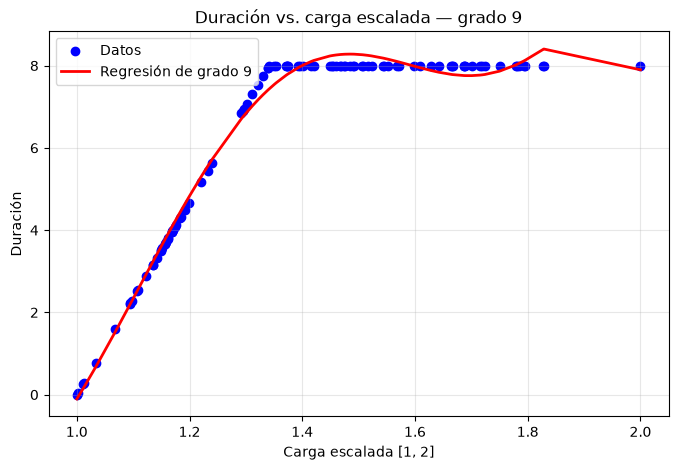

In [99]:
# Ordenar los valores para que la curva no aparezca quebrada
orden_bateria_esc = np.argsort(x_bateria_esc_v[:, 0])

plt.figure(figsize=(8, 5))

plt.scatter(
    x_bateria_esc_v[:, 0],
    y_bateria["duracion"],
    color="blue",
    label="Datos"
)

plt.plot(
    x_bateria_esc_v[orden_bateria_esc, 0],
    predicciones_bateria_9_esc[orden_bateria_esc, 0],
    color="red",
    linewidth=2,
    label="Regresión de grado 9"
)

plt.xlabel("Carga escalada [1, 2]")
plt.ylabel("Duración")
plt.title("Duración vs. carga escalada — grado 9")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Ahora con salarios

## **Modificar el rango de [1988.25,2018] a [1,2]**

In [100]:
# Escalamiento manual de Periodo: [1988.25, 2018] -> [1, 2]

periodo_min = 1988.25
periodo_max = 2018.00

df_salarios["Periodo_escalado"] = (
    1
    + ((df_salarios["Periodo"] - periodo_min)
       / (periodo_max - periodo_min))
    * (2 - 1)
)

df_salarios[["Periodo", "Periodo_escalado", "Salario"]]

,Periodo,Periodo_escalado,Salario
0,1988.25,1.000000,8.00
1,1989.00,1.025210,8.64
2,1989.50,1.042017,9.16
3,1990.00,1.058824,10.08
4,1990.84,1.087059,11.90
5,1991.84,1.120672,13.33
6,1993.00,1.159664,14.27
7,1994.00,1.193277,15.27
8,1995.00,1.226891,16.34
9,1995.30,1.236975,18.30


In [101]:
print("Mínimo:", df_salarios["Periodo_escalado"].min())
print("Máximo:", df_salarios["Periodo_escalado"].max())

Mínimo: 1.0
Máximo: 2.0


## Regresión de grado 9

In [102]:
# Variables del modelo
x_salarios_esc = df_salarios[["Periodo_escalado"]]
y_salarios = df_salarios[["Salario"]]

x_salarios_esc_v = np.reshape(
    x_salarios_esc.values,
    (-1, 1)
)

# Construcción manual de las potencias
X_salarios_9_esc = np.hstack([
    x_salarios_esc_v,
    x_salarios_esc_v**2,
    x_salarios_esc_v**3,
    x_salarios_esc_v**4,
    x_salarios_esc_v**5,
    x_salarios_esc_v**6,
    x_salarios_esc_v**7,
    x_salarios_esc_v**8,
    x_salarios_esc_v**9
])

# Ajustar el modelo
modelo_salarios_9_esc = LinearRegression()
modelo_salarios_9_esc.fit(X_salarios_9_esc, y_salarios)

# Predicciones
predicciones_salarios_9_esc = modelo_salarios_9_esc.predict(
    X_salarios_9_esc
)

R2_salarios_9_esc = modelo_salarios_9_esc.score(
    X_salarios_9_esc,
    y_salarios
)

print("B0:", modelo_salarios_9_esc.intercept_)
print("B1 a B9:", modelo_salarios_9_esc.coef_)
print(f"R² del modelo escalado de grado 9: {R2_salarios_9_esc:.6f}")
print(f"Porcentaje explicado: {R2_salarios_9_esc * 100:.2f}%")

B0: [243.18999634]
B1 a B9: [[-214.05908388 -188.94513213  -14.17198586  156.92786088  160.81339452
   -43.60804079 -200.99737651  133.95749415  -24.00458891]]
R² del modelo escalado de grado 9: 0.996148
Porcentaje explicado: 99.61%


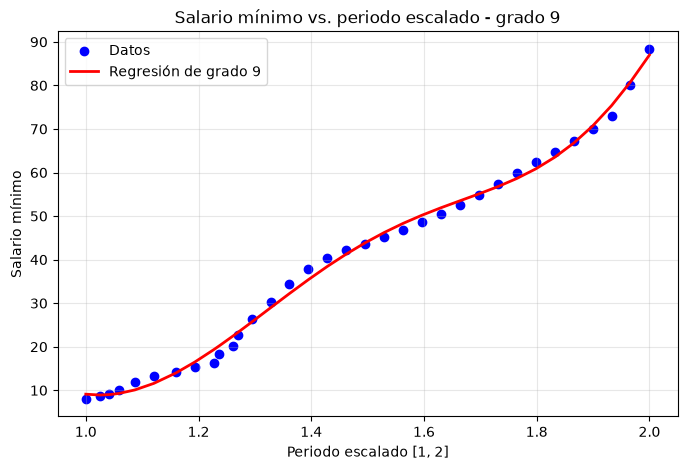

In [103]:
# Ordenar los valores para dibujar correctamente la curva
orden_salarios_esc = np.argsort(x_salarios_esc_v[:, 0])

plt.figure(figsize=(8, 5))

plt.scatter(
    x_salarios_esc_v[:, 0],
    y_salarios["Salario"],
    color="blue",
    label="Datos"
)

plt.plot(
    x_salarios_esc_v[orden_salarios_esc, 0],
    predicciones_salarios_9_esc[orden_salarios_esc, 0],
    color="red",
    linewidth=2,
    label="Regresión de grado 9"
)

plt.xlabel("Periodo escalado [1, 2]")
plt.ylabel("Salario mínimo")
plt.title("Salario mínimo vs. periodo escalado - grado 9")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Estándar

In [104]:
# Escalamiento estándar de la carga
df_bateria["carga_estandar"] = (
    df_bateria["carga"] - 4.573
) / 2.7886025246356

df_bateria[["carga_estandar"]].describe()

,carga_estandar
count,1.000000e+02
mean,-1.398881e-16
std,1.000000e+00
min,-1.639890e+00
25%,-9.271669e-01
50%,-7.100331e-02
75%,6.990957e-01
max,2.562932e+00


In [105]:
# Variables estandarizadas
x_bateria_estandar = df_bateria[["carga_estandar"]]
y_bateria = df_bateria[["duracion"]]

x_bateria_estandar_v = np.reshape(
    x_bateria_estandar.values,
    (-1, 1)
)

In [106]:
# Modelo de noveno orden con carga estandarizada
X_bateria_9_estandar = np.hstack([
    x_bateria_estandar_v,
    x_bateria_estandar_v**2,
    x_bateria_estandar_v**3,
    x_bateria_estandar_v**4,
    x_bateria_estandar_v**5,
    x_bateria_estandar_v**6,
    x_bateria_estandar_v**7,
    x_bateria_estandar_v**8,
    x_bateria_estandar_v**9
])

modelo_bateria_9_estandar = LinearRegression()

modelo_bateria_9_estandar.fit(
    X_bateria_9_estandar,
    y_bateria
)

predicciones_bateria_9_estandar = (
    modelo_bateria_9_estandar.predict(
        X_bateria_9_estandar
    )
)

R2_bateria_9_estandar = (
    modelo_bateria_9_estandar.score(
        X_bateria_9_estandar,
        y_bateria
    )
)

print("B0:", modelo_bateria_9_estandar.intercept_)
print("B1 a B9:", modelo_bateria_9_estandar.coef_)

print(
    f"R² del modelo de noveno orden: "
    f"{R2_bateria_9_estandar:.6f}"
)

print(
    f"Porcentaje explicado: "
    f"{R2_bateria_9_estandar * 100:.2f}%"
)

B0: [8.07892173]
B1 a B9: [[ 0.87305015 -3.8335034   2.66564513  2.1427503  -1.77019112 -0.71117705
   0.50914141  0.08629359 -0.05190043]]
R² del modelo de noveno orden: 0.998913
Porcentaje explicado: 99.89%


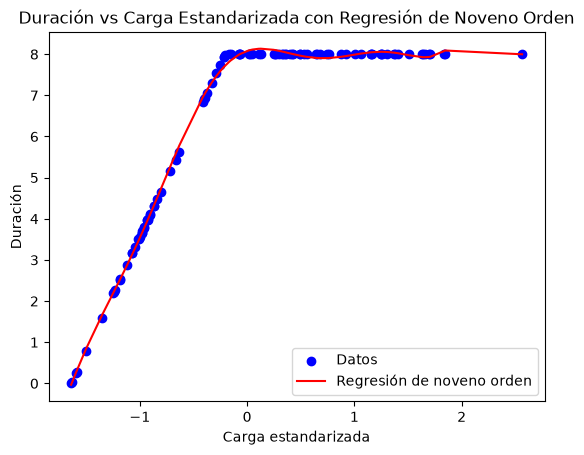

In [107]:
# Gráfica del modelo de noveno orden
orden_bateria_estandar = np.argsort(
    x_bateria_estandar_v[:, 0]
)

plt.scatter(
    x_bateria_estandar_v,
    y_bateria,
    color="blue",
    label="Datos"
)

plt.plot(
    x_bateria_estandar_v[orden_bateria_estandar],
    predicciones_bateria_9_estandar[
        orden_bateria_estandar
    ],
    color="red",
    label="Regresión de noveno orden"
)

plt.xlabel("Carga estandarizada")
plt.ylabel("Duración")
plt.title(
    "Duración vs Carga Estandarizada "
    "con Regresión de Noveno Orden"
)
plt.legend()
plt.show()

## Pipeline, Ingeniería de características

In [108]:
x_salarios = df_salarios[["Periodo"]]
y_salarios = df_salarios[["Salario"]]

In [109]:
from sklearn.preprocessing import StandardScaler

scaler_salarios = StandardScaler()

# Aprender la media y desviación del Periodo
scaler_salarios.fit(x_salarios)

# Transformar los años
x_salarios_scaled = scaler_salarios.transform(
    x_salarios
)

print(x_salarios_scaled)

[[-1.550472  ]
 [-1.46697774]
 [-1.4113149 ]
 [-1.35565206]
 [-1.26213849]
 [-1.15081282]
 [-1.02167503]
 [-0.91034935]
 [-0.79902368]
 [-0.76562597]
 [-0.687698  ]
 [-0.6543003 ]
 [-0.57637232]
 [-0.46504664]
 [-0.35372097]
 [-0.24239529]
 [-0.13106961]
 [-0.01974394]
 [ 0.09158174]
 [ 0.20290742]
 [ 0.3142331 ]
 [ 0.42555877]
 [ 0.53688445]
 [ 0.64821013]
 [ 0.7595358 ]
 [ 0.87086148]
 [ 0.98218716]
 [ 1.09351284]
 [ 1.20483851]
 [ 1.31616419]
 [ 1.42748987]
 [ 1.53881554]
 [ 1.65014122]
 [ 1.7614669 ]]


In [110]:
print(
    "Media:",
    np.mean(x_salarios_scaled)
)

print(
    "Desviación estándar:",
    np.std(x_salarios_scaled)
)

Media: 4.486607164220486e-15
Desviación estándar: 0.9999999999999999


## Regresión de grado 9

In [111]:
X_salarios_9_scaled = np.hstack([
    x_salarios_scaled,
    x_salarios_scaled**2,
    x_salarios_scaled**3,
    x_salarios_scaled**4,
    x_salarios_scaled**5,
    x_salarios_scaled**6,
    x_salarios_scaled**7,
    x_salarios_scaled**8,
    x_salarios_scaled**9
])

modelo_salarios_9_scaled = LinearRegression()

modelo_salarios_9_scaled.fit(
    X_salarios_9_scaled,
    y_salarios
)

predicciones_salarios_9_scaled = (
    modelo_salarios_9_scaled.predict(
        X_salarios_9_scaled
    )
)

R2_salarios_9_scaled = (
    modelo_salarios_9_scaled.score(
        X_salarios_9_scaled,
        y_salarios
    )
)

print(
    "B0:",
    modelo_salarios_9_scaled.intercept_
)

print(
    "B1 a B9:",
    modelo_salarios_9_scaled.coef_
)

print(
    f"R² del modelo de noveno orden: "
    f"{R2_salarios_9_scaled:.6f}"
)

print(
    f"Porcentaje explicado: "
    f"{R2_salarios_9_scaled * 100:.2f}%"
)

B0: [43.07591082]
B1 a B9: [[ 15.58811167 -23.80695298  29.40377818  30.39907048 -34.24755276
  -14.92123884  14.82753989   2.60028328  -2.18348056]]
R² del modelo de noveno orden: 0.999466
Porcentaje explicado: 99.95%


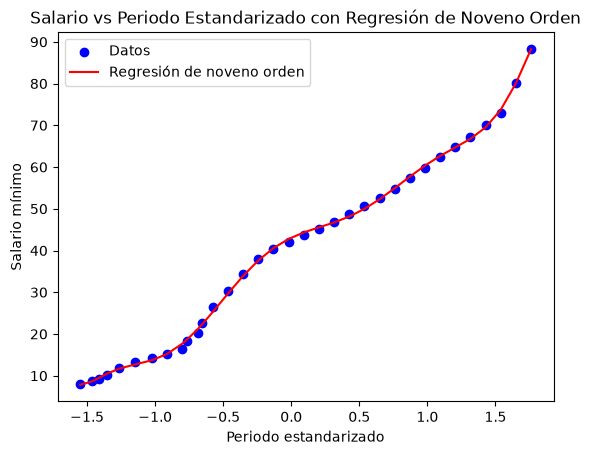

In [112]:
orden_salarios_scaled = np.argsort(
    x_salarios_scaled[:, 0]
)

plt.scatter(
    x_salarios_scaled,
    y_salarios,
    color="blue",
    label="Datos"
)

plt.plot(
    x_salarios_scaled[orden_salarios_scaled],
    predicciones_salarios_9_scaled[
        orden_salarios_scaled
    ],
    color="red",
    label="Regresión de noveno orden"
)

plt.xlabel("Periodo estandarizado")
plt.ylabel("Salario mínimo")
plt.title(
    "Salario vs Periodo Estandarizado "
    "con Regresión de Noveno Orden"
)
plt.legend()
plt.show()